# LSTM — TensorFlow IMDB Pipeline (Part B)

## Model: Long Short-Term Memory (LSTM) with Embedding
- **Dataset**: IMDB Sentiment Analysis — 25,000 train / 25,000 test, 300-token sequences, binary classification
- **Task**: Classify movie reviews as positive or negative — mirror PyTorch IMDB pipeline
- **Framework showcase**: Keras Embedding + LSTM with model.fit, CPU baseline comparison
- **Device**: CPU (Windows) — PT trained in 25s, CPU is sufficient

## Evaluation Strategy
- **Primary metric**: Accuracy + F1 (balanced binary classification)
- **Note**: Architecture sweep + sequence length ablation covered in PT pipeline, skipped here (CPU too slow)

## Pipeline
1. Load padded IMDB data + config
2. Embedding + LSTM model (baseline)
3. Evaluation + benchmarks
4. Save results + cross-framework comparison

In [1]:
# Step 1: Setup
"""
Load preprocessed IMDB data (padded to 300 tokens, 10K vocab).
Binary sentiment — no class weights needed (balanced 50/50).
CPU training — PT trained in 25s, CPU will be ~5-10 min.
"""

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
from tensorflow import keras
import json
import sys
sys.path.append('../..')

from utils.metrics import evaluate_classifier
from utils.visualization import plot_training_history, plot_confusion_matrix
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
MODEL_NAME = "LSTM"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 64
VOCAB_SIZE = 10001  # 10K words + padding index 0
EMBED_DIM = 128
MAX_LENGTH = 300
N_CLASSES = 2

tf.random.set_seed(RANDOM_STATE)

# Load IMDB data
imdb_dir = '../../data/processed/lstm/imdb'
X_train = np.load(f'{imdb_dir}/X_train.npy')
X_test = np.load(f'{imdb_dir}/X_test.npy')
y_train = np.load(f'{imdb_dir}/y_train.npy')
y_test = np.load(f'{imdb_dir}/y_test.npy')

with open(f'{imdb_dir}/preprocessing_info.json', 'r') as f:
    metadata = json.load(f)

with open(f'{imdb_dir}/word_index.json', 'r') as f:
    word_index = json.load(f)

# Reverse index for decoding
reverse_index = {v + 3: k for k, v in word_index.items()}
reverse_index[0] = '<PAD>'
reverse_index[1] = '<START>'
reverse_index[2] = '<UNK>'

def decode_review(sequence):
    words = [reverse_index.get(int(i), '?') for i in sequence if i != 0]
    return ' '.join(words)

# Train/val split (10%)
np.random.seed(RANDOM_STATE)
n_val = int(len(X_train) * 0.1)
perm = np.random.permutation(len(X_train))
val_idx, tr_idx = perm[:n_val], perm[n_val:]

X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
X_val, y_val = X_train[val_idx], y_train[val_idx]

print("=" * 60)
print(f"[1/4] {FRAMEWORK} — {MODEL_NAME} IMDB Pipeline")
print("=" * 60)
print(f"Device: CPU (Windows)")
print(f"TF version: {tf.__version__}")
print(f"Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Vocab: {VOCAB_SIZE:,} | Embedding: {EMBED_DIM} | Max length: {MAX_LENGTH}")
print(f"Classes: Negative (0), Positive (1) — balanced 50/50")
print(f"Batch size: {BATCH_SIZE}")
print(f"\nPT best: LSTM-128, 87.8% acc, 0.883 F1, 0.946 AUC")

[1/4] TensorFlow — LSTM IMDB Pipeline
Device: CPU (Windows)
TF version: 2.20.0
Train: (22500, 300) | Val: (2500, 300) | Test: (25000, 300)
Vocab: 10,001 | Embedding: 128 | Max length: 300
Classes: Negative (0), Positive (1) — balanced 50/50
Batch size: 64

PT best: LSTM-128, 87.8% acc, 0.883 F1, 0.946 AUC


In [2]:
# Step 2: Embedding + LSTM Model
"""
Keras Embedding + LSTM for binary sentiment classification.
Same architecture as PT: Embedding(10001, 128) -> LSTM(128, 2L) -> Dense(1).
Uses model.fit() with EarlyStopping on val_accuracy.
"""

print("=" * 60)
print("[2/4] Embedding + LSTM Model")
print("=" * 60)

model = keras.Sequential([
    keras.layers.Input(shape=(MAX_LENGTH,)),
    keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True),
    keras.layers.LSTM(128, return_sequences=True, dropout=0.3),
    keras.layers.LSTM(128, dropout=0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

n_params = model.count_params()
print(f"Architecture: Embedding(10001, 128) -> LSTM(128, 2L, drop=0.3) -> Dense(1)")
print(f"Parameters: {n_params:,}")

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

with track_performance() as perf_baseline:
    hist_raw = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

hist_baseline = {
    'train_loss': hist_raw.history['loss'],
    'val_loss': hist_raw.history['val_loss'],
    'train_acc': hist_raw.history['accuracy'],
    'val_acc': hist_raw.history['val_accuracy'],
    'epochs': len(hist_raw.history['loss']),
    'best_val_acc': max(hist_raw.history['val_accuracy'])
}

# Test evaluation
test_proba = model.predict(X_test, verbose=0).ravel()
test_preds = (test_proba > 0.5).astype(int)
baseline_metrics = evaluate_classifier(y_test, test_preds, test_proba)

print(f"\nEpochs: {hist_baseline['epochs']} | Best val acc: {hist_baseline['best_val_acc']:.4f}")
print(f"Training time: {perf_baseline['time']:.2f}s")
print(f"\nTest Results:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\nPT comparison: 87.8% acc, 0.883 F1, 0.946 AUC")

[2/4] Embedding + LSTM Model
Architecture: Embedding(10001, 128) -> LSTM(128, 2L, drop=0.3) -> Dense(1)
Parameters: 1,543,425

Epochs: 6 | Best val acc: 0.8748
Training time: 1410.10s

Test Results:
  accuracy: 0.8652
  precision: 0.8357
  recall: 0.9090
  f1: 0.8708
  auc: 0.9395
  log_loss: 0.3540
  brier_score: 0.1045
  ece: 0.3949

PT comparison: 87.8% acc, 0.883 F1, 0.946 AUC


[3/4] Evaluation + Benchmarks


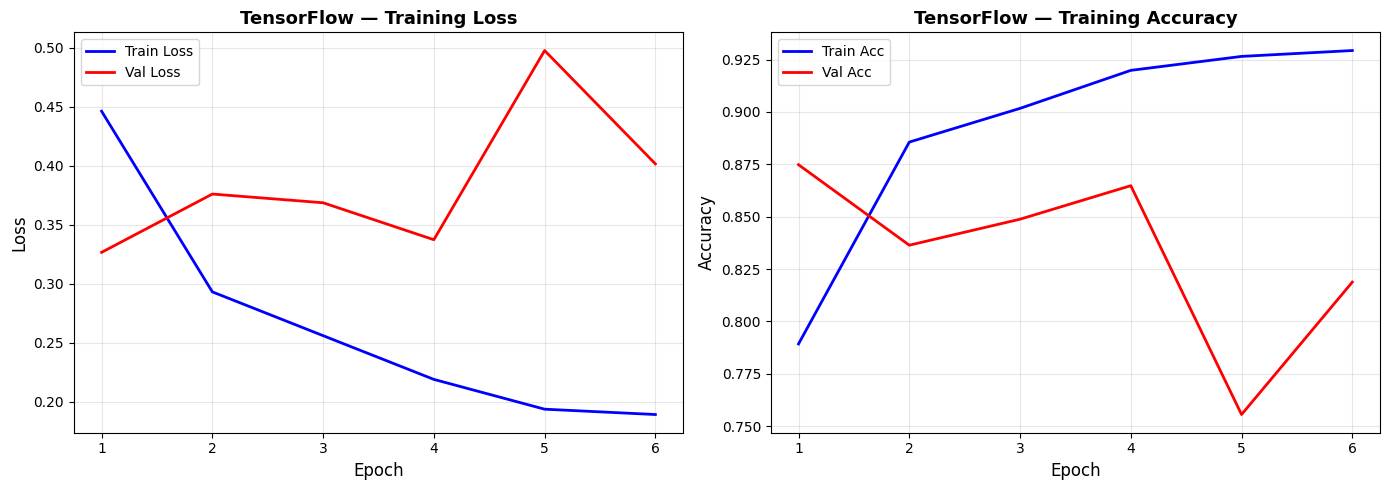

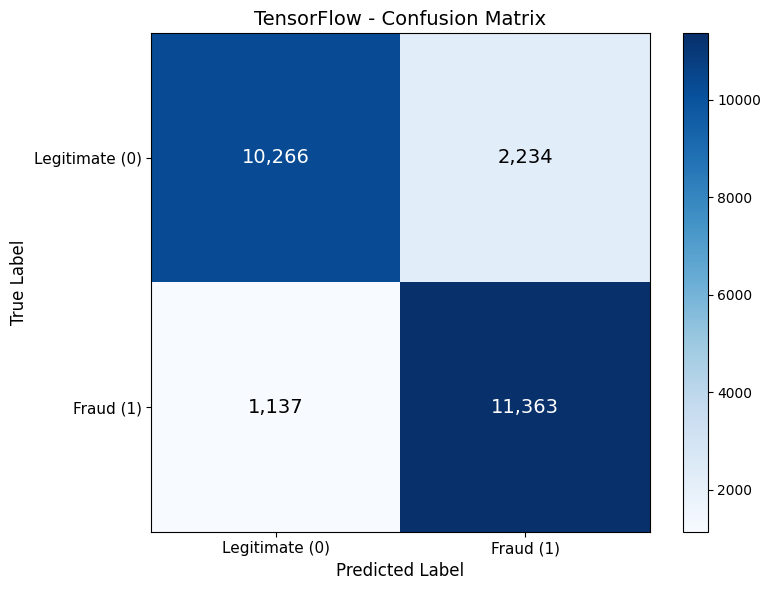


Inference (3 runs x 25000 samples):
  Per sample: 1989.37 us
  Throughput: 503 samples/sec

Model size: 6,173,700 bytes (5.89 MB)
Training time: 1410s (23.5 min)

PT comparison:
  PT: 22.83 us/sample, 5.89 MB, 25s training (GPU)
  TF: 1989.37 us/sample, 5.89 MB, 1410s training (CPU)

Note: Architecture sweep + length ablation skipped (PT covered these,
TF CPU would take 5+ hours for 8 additional model trainings)


In [3]:
# Step 3: Evaluation + Benchmarks
"""
Training history, confusion matrix, inference timing.
Skip architecture sweep + length ablation — PT covered these
and TF CPU would take 5+ hours. Baseline confirmation is sufficient.
"""

print("=" * 60)
print("[3/4] Evaluation + Benchmarks")
print("=" * 60)

# Training history
plot_training_history(hist_baseline, framework=FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history.png')

# Confusion matrix
plot_confusion_matrix(y_test, test_preds, framework=FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/confusion_matrix.png')

# Inference timing
def predict_fn(X):
    return (model.predict(X, verbose=0).ravel() > 0.5).astype(int)

inference = track_inference(predict_fn, X_test, n_runs=3)
model_size = get_model_size(model, framework='tensorflow')

print(f"\nInference ({3} runs x {len(X_test)} samples):")
print(f"  Per sample: {inference['per_sample_us']:.2f} us")
print(f"  Throughput: {inference['samples_per_sec']:,.0f} samples/sec")
print(f"\nModel size: {model_size:,} bytes ({model_size / (1024*1024):.2f} MB)")
print(f"Training time: {perf_baseline['time']:.0f}s ({perf_baseline['time']/60:.1f} min)")

print(f"\nPT comparison:")
print(f"  PT: 22.83 us/sample, 5.89 MB, 25s training (GPU)")
print(f"  TF: {inference['per_sample_us']:.2f} us/sample, {model_size / (1024*1024):.2f} MB, {perf_baseline['time']:.0f}s training (CPU)")
print(f"\nNote: Architecture sweep + length ablation skipped (PT covered these,")
print(f"TF CPU would take 5+ hours for 8 additional model trainings)")

In [4]:
# Step 4: Save Results
"""
Save LSTM-128 IMDB results for cross-framework comparison.
"""

print("=" * 60)
print("[4/4] Save Results")
print("=" * 60)

model.save_weights(f'{RESULTS_DIR}/lstm_imdb_best.weights.h5')
print(f"Model saved: {RESULTS_DIR}/lstm_imdb_best.weights.h5")

results = build_results_dict(
    framework=FRAMEWORK,
    model_name='LSTM',
    test_metrics=baseline_metrics,
    perf=perf_baseline,
    inference_stats=inference,
    model_size=model_size,
    dataset='IMDB Sentiment',
    architecture='Embedding(10001,128) -> LSTM(128, 2L, drop=0.3) -> Dense(1)',
    n_params=int(n_params),
    epochs=int(hist_baseline['epochs']),
    best_val_acc=float(hist_baseline['best_val_acc']),
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    max_length=MAX_LENGTH,
    device='CPU',
    note='Architecture sweep + length ablation skipped (PT covered, CPU too slow)',
)

save_results(results, RESULTS_DIR)
add_result('lstm_imdb', results)
print_comparison('lstm_imdb')

[4/4] Save Results
Model saved: results/lstm_imdb_best.weights.h5
    Results saved to: results\metrics.json
    Added 'TensorFlow' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\lstm_imdb.json
    Frameworks: 2 recorded

CROSS-FRAMEWORK COMPARISON: LSTM_IMDB
Metric                                                                                          PyTorch                                                               TensorFlow
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
model                                                                                              LSTM                                                                     LSTM
training_time                                                                                   24.74 s                                                                 23.5